# CardioCare — EDA & Preprocessing (Task 1 / §5.1)

**Goal.** Understand the UCI Heart Disease data, then derive a *reusable*
preprocessing pipeline (no one-off cells). Every preprocessing decision below is
implemented in `src/preprocessing.py` so it re-applies identically to new data
inside an sklearn `Pipeline` — which also guarantees **no data leakage** (all
learnable transforms fit only on the training fold).

> **Ethical framing.** CardioCare is an *assistive* tool: it **informs, it does
> not decide**. Outputs are decision-support for a cardiologist, never an
> autonomous diagnosis.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from preprocessing import (load_heart_data, binarize_target, clean_frame,
                           validate_input_ranges, build_preprocessor,
                           build_model_pipeline, split_X_y,
                           NUMERIC_FEATURES, CATEGORICAL_FEATURES)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load the data

In [2]:
df_raw = load_heart_data(ROOT / "data" / "heart.csv")
print("shape:", df_raw.shape)
df_raw.head()

shape: (920, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67,1,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67,1,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37,1,3,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41,0,2,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    int64  
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 100.8 KB


In [4]:
df_raw.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,861.000000,890.000000,830.000000,918.000000,865.000000,865.000000,858.000000,611.000000,309.000000,434.000000,920.000000
mean,53.510870,0.789130,3.250000,132.132404,199.130337,0.166265,0.604575,137.545665,0.389595,0.878788,1.770867,0.676375,5.087558,0.995652
std,9.424685,0.408148,0.930969,19.066070,110.780810,0.372543,0.805827,25.926276,0.487941,1.091226,0.619256,0.935653,1.919075,1.142693
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,175.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,268.000000,0.000000,1.000000,157.000000,1.000000,1.500000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 2. Target class distribution

The raw target is multiclass (0 = no disease, 1–4 = increasing severity). We
binarise it (`>0 -> 1`). We then inspect the class balance, because it dictates
**which metric we trust**.

target
0    0.446739
1    0.553261
Name: proportion, dtype: float64


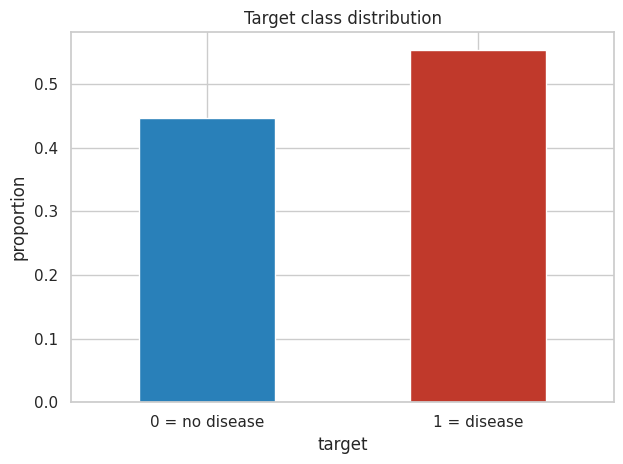

In [5]:
df = binarize_target(df_raw)
dist = df["target"].value_counts(normalize=True).sort_index()
print(dist)
ax = dist.plot(kind="bar", color=["#2980b9", "#c0392b"])
ax.set_xticklabels(["0 = no disease", "1 = disease"], rotation=0)
ax.set_ylabel("proportion"); ax.set_title("Target class distribution")
plt.tight_layout(); plt.show()

**Why this matters for metric choice.** The classes are only mildly
imbalanced, but plain *accuracy* would still reward a model that simply favours
the majority class. Because a **false negative** (missing a real heart-disease
case) is the dangerous error in cardiology, we evaluate with
**balanced accuracy, precision, recall, F1 and the confusion matrix**, and we
ultimately select the final model with a **recall-first** criterion.

## 3. Missing values — per column and total

In [6]:
miss = df.isna().sum()
print("Missing per column:")
print(miss[miss > 0] if miss.any() else "None")
print("\nTotal missing cells:", int(df.isna().sum().sum()))

Missing per column:
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Total missing cells: 1759


## 4. Duplicate rows and empty columns

In [7]:
print("Exact duplicate rows:", int(df.duplicated().sum()))
empty_cols = [c for c in df.columns if df[c].isna().all()]
print("Fully-empty columns:", empty_cols or "None")

Exact duplicate rows: 2
Fully-empty columns: None


## 5. Outliers on continuous features (boxplots + IQR)

We inspect `age, trestbps, chol, thalach, oldpeak`.

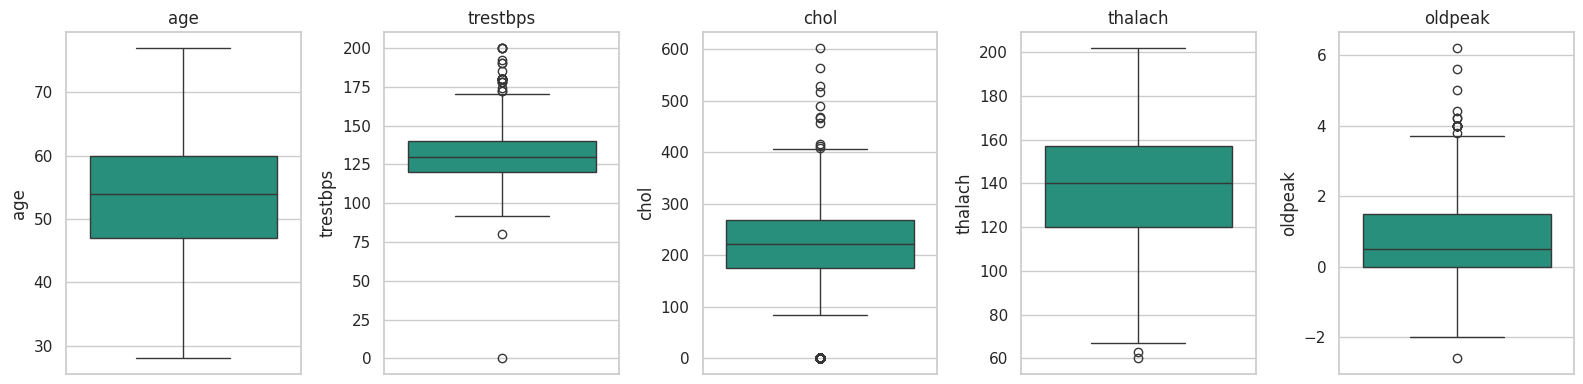

IQR-based outlier counts:
  age      :   0 outside [27.5, 79.5]
  trestbps :  28 outside [90.0, 170.0]
  chol     : 183 outside [35.5, 407.5]
  thalach  :   2 outside [64.5, 212.5]
  oldpeak  :  16 outside [-2.25, 3.75]


In [8]:
cont = NUMERIC_FEATURES
fig, axes = plt.subplots(1, len(cont), figsize=(16, 4))
for ax, feat in zip(axes, cont):
    sns.boxplot(y=df[feat], ax=ax, color="#16a085")
    ax.set_title(feat)
plt.tight_layout(); plt.show()

def iqr_outliers(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), round(lo, 2), round(hi, 2)

print("IQR-based outlier counts:")
for feat in cont:
    n, lo, hi = iqr_outliers(df[feat])
    print(f"  {feat:9s}: {n:3d} outside [{lo}, {hi}]")

## 6. Clinical range validation

In [9]:
validate_input_ranges(df)

,feature,lo,hi,n_out_of_range,valid
0,age,18,120,0,True
1,trestbps,0,250,0,True
2,chol,0,600,1,False
3,thalach,0,250,0,True
4,oldpeak,0,10,12,False


## 7. Correlation snapshot (continuous features vs target)

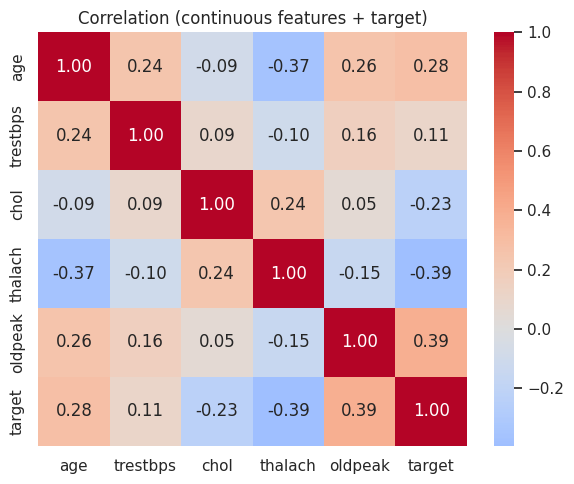

In [10]:
corr = df[cont + ["target"]].apply(pd.to_numeric, errors="coerce").corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation (continuous features + target)")
plt.tight_layout(); plt.show()

## 8. What the EDA told us → preprocessing decisions

| Observation (EDA) | Decision (in `src/preprocessing.py`) |
|---|---|
| A few missing values in `ca`, `thal`, `chol` | **Impute, don't drop columns** — they are clinically informative. Numeric → **median** (robust to outliers); categorical → **most_frequent**. |
| Continuous features on very different scales (`chol` ~200s vs `oldpeak` ~0–6) | **StandardScaler** on numeric features (essential for LogisticRegression / SVC). |
| Coded categoricals (`cp`, `thal`, `slope`, `ca`, …) are **not ordinal-safe** | **OneHotEncoder(handle_unknown="ignore")** so unseen categories at inference don't crash. |
| Real but plausible outliers (high `chol`, `oldpeak`) | **Keep** them — they carry genuine clinical risk signal. We *validate* impossible values (range checks) instead of clipping real extremes. |
| 1 exact duplicate row, possible empty columns | Drop duplicates & all-NaN columns in `clean_frame()` (dataset hygiene, learns nothing → no leakage). |
| Mild class imbalance + costly false negatives | Evaluate with balanced accuracy / recall / F1 / confusion matrix; `class_weight="balanced"`; **recall-first** final selection. |

**Leakage guard.** All imputers, the scaler, the encoder, and the optional
feature selector live *inside* the `Pipeline` and are fit **after**
`train_test_split`, on the training fold only.

## 9. The reusable pipeline (proof it fits & transforms)

In [11]:
df_clean = clean_frame(binarize_target(load_heart_data(ROOT / "data" / "heart.csv")))
X, y = split_X_y(df_clean)

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

pre = build_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)
Xt = pre.fit_transform(X_tr)            # fit on TRAIN ONLY -> no leakage
print("transformed train shape:", Xt.shape)

from sklearn.linear_model import LogisticRegression
pipe = build_model_pipeline(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                       class_weight="balanced"),
    NUMERIC_FEATURES, CATEGORICAL_FEATURES)
pipe.fit(X_tr, y_tr)
print("held-out accuracy:", round(pipe.score(X_te, y_te), 3))

transformed train shape: (734, 28)
held-out accuracy: 0.821


**Next:** `src/train.py` trains ≥3 model families, logs everything to
MLflow, runs 5-fold CV + hyperparameter tuning, and selects the final model on a
recall-first clinical criterion. See `README.md`.